Name: Rafay Raza

GWID: G40856805

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Loading
# Load the dataset

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape[0]

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:
# Data Preprocessing
# Clean and prepare the dataset

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid",
        "c_jail_in", "c_jail_out"
    ]
].copy()

# Filters
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Convert datetime
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

# Create factors
df["crime_factor"] = df["c_charge_degree"]

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = np.where(df["score_text"] == "Low", 0, 1)

df.shape[0]

6172

In [5]:
# Exploratory Data Analysis (EDA)
# Examine the structure of the dataset using summary statistics and visualizations. This helps to understand the distribution of key variables such as race, gender, and risk scores.

In [6]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

In [7]:
# Summary of age categories
print("── Age Category ──")
print(df["age_cat"].value_counts())

── Age Category ──
age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [8]:
# Summary of race
print("\n── Race ──")
print(df["race"].value_counts())


── Race ──
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [9]:
# Percentage breakdown
n = len(df)
print(f"\nBlack defendants:          {df['race'].value_counts()['African-American'] / n * 100:.2f}%")
print(f"White defendants:          {df['race'].value_counts()['Caucasian'] / n * 100:.2f}%")
print(f"Hispanic defendants:       {df['race'].value_counts()['Hispanic'] / n * 100:.2f}%")
print(f"Asian defendants:          {df['race'].value_counts()['Asian'] / n * 100:.2f}%")
print(f"Native American defendants:{df['race'].value_counts()['Native American'] / n * 100:.2f}%")



Black defendants:          51.44%
White defendants:          34.07%
Hispanic defendants:       8.25%
Asian defendants:          0.50%
Native American defendants:0.18%


In [10]:
# Summary of score_text
print("\n── Score Text ──")
print(df["score_text"].value_counts())


── Score Text ──
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [11]:
# Summary of sex
print("\n── Sex ──")
print(df["sex"].value_counts())
print(f"\nMen:   {df['sex'].value_counts()['Male'] / n * 100:.2f}%")
print(f"Women: {df['sex'].value_counts()['Female'] / n * 100:.2f}%")


── Sex ──
sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [12]:
# Two-year recidivism count
print("\n── Two-Year Recidivism ──")
print(f"Recidivated: {df['two_year_recid'].sum()} ({df['two_year_recid'].sum() / n * 100:.2f}%)")


── Two-Year Recidivism ──
Recidivated: 2809 (45.51%)


In [13]:
df["race_factor"].value_counts()
df["gender_factor"].value_counts()
df["score_factor"].value_counts()

,count
score_factor,
0,3421
1,2751


In [14]:
# Sex x Race Crosstab
print("\n── Sex x Race Crosstab ──")
print(pd.crosstab(df["sex"], df["race"]))


── Sex x Race Crosstab ──
race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [15]:
# Correlation
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
corr = df["length_of_stay"].corr(df["decile_score"])
print(f"\nCorrelation between length of stay and decile score: {corr:.4f}")


Correlation between length of stay and decile score: 0.2075


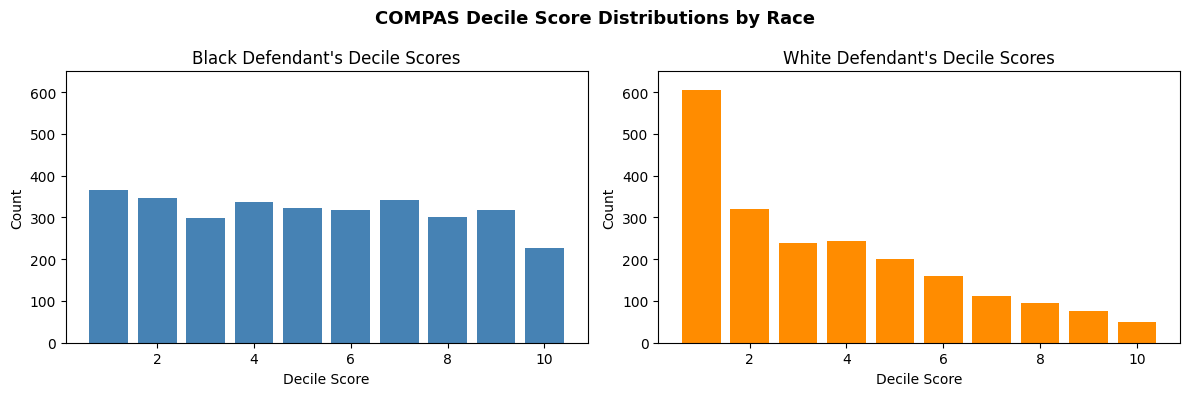

In [16]:
# Decile Score Bar Charts (Black vs White)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

black_df = df[df["race"] == "African-American"]
black_counts = black_df["decile_score"].value_counts().sort_index()
axes[0].bar(black_counts.index, black_counts.values, color="steelblue")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_df = df[df["race"] == "Caucasian"]
white_counts = white_df["decile_score"].value_counts().sort_index()
axes[1].bar(white_counts.index, white_counts.values, color="darkorange")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.suptitle("COMPAS Decile Score Distributions by Race", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

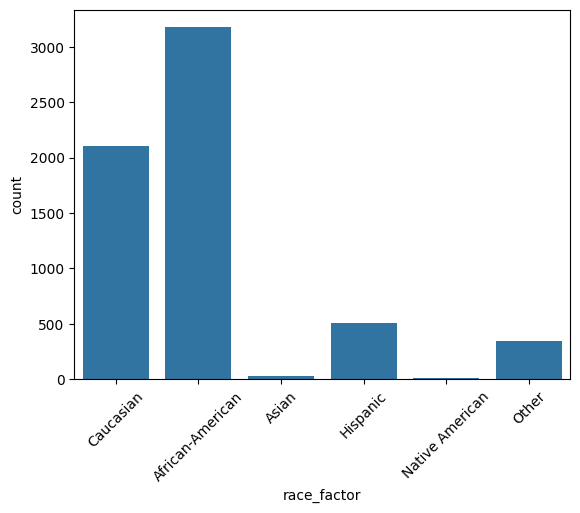

In [17]:
sns.countplot(data=df, x="race_factor")
plt.xticks(rotation=45)
plt.show()

In [18]:
# Logistic Regression Model

# Implement a logistic regression model to predict the likelihood of a defendant receiving a high-risk score.

In [19]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.logit(
    "score_factor ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        13:57:35   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

In [20]:
# Model Interpretation

# Model coefficients are converted into odds ratios to better understand the effect of each variable on the likelihood of receiving a high-risk score.

In [21]:
np.exp(model.params)

,0
Intercept,0.217504
C(gender_factor)[T.Female],1.247656
C(age_factor)[T.Less than 25],3.700213
C(age_factor)[T.Greater than 45],0.257784
C(race_factor)[T.African-American],1.611567
C(race_factor)[T.Asian],0.775370
C(race_factor)[T.Hispanic],0.651554
C(race_factor)[T.Native American],4.031779
C(race_factor)[T.Other],0.437645
C(crime_factor)[T.M],0.732537


In [22]:
## Predictions and Model Evaluation

## Generate predicted probabilities and classify observations using a 0.5 threshold. Model performance is evaluated using:
## confusion matrix
## accuracy
## precision
## recall
## false positive rate (FPR)
## false negative rate (FNR)

In [23]:
df["pred_prob"] = model.predict(df)

In [24]:
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, 1, 0)

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df["two_year_recid"], df["pred_class"])
cm

array([[2653,  710],
       [ 945, 1864]])

In [26]:
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

accuracy, precision, recall, FPR, FNR

(np.float64(0.731853532080363),
 np.float64(0.7241647241647242),
 np.float64(0.6635813456746174),
 np.float64(0.21112102289622361),
 np.float64(0.3364186543253827))

In [27]:
## Fairness Analysis

## Evaluate model performance across racial groups by computing error rates (FPR and FNR) for each group.

In [28]:
race_metrics = df.groupby("race_factor", observed=False).apply(
    lambda x: pd.Series({
        "TP": ((x["pred_class"] == 1) & (x["two_year_recid"] == 1)).sum(),
        "TN": ((x["pred_class"] == 0) & (x["two_year_recid"] == 0)).sum(),
        "FP": ((x["pred_class"] == 1) & (x["two_year_recid"] == 0)).sum(),
        "FN": ((x["pred_class"] == 0) & (x["two_year_recid"] == 1)).sum(),
    }),
    include_groups=False
)

race_metrics["FPR"] = race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])
race_metrics["FNR"] = race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])

race_metrics

,TP,TN,FP,FN,FPR,FNR
race_factor,,,,,,
Caucasian,381,1148,133,441,0.103825,0.536496
African-American,1373,959,555,288,0.366579,0.173390
Asian,2,22,1,6,0.043478,0.750000
Hispanic,81,306,14,108,0.043750,0.571429
Native American,5,2,4,0,0.666667,0.000000
Other,22,216,3,102,0.013699,0.822581


In [29]:
ref = race_metrics.loc["Caucasian"]

race_metrics["delta_FPR"] = race_metrics["FPR"] - ref["FPR"]
race_metrics["delta_FNR"] = race_metrics["FNR"] - ref["FNR"]

race_metrics

,TP,TN,FP,FN,FPR,FNR,delta_FPR,delta_FNR
race_factor,,,,,,,,
Caucasian,381,1148,133,441,0.103825,0.536496,0.000000,0.000000
African-American,1373,959,555,288,0.366579,0.173390,0.262753,-0.363107
Asian,2,22,1,6,0.043478,0.750000,-0.060347,0.213504
Hispanic,81,306,14,108,0.043750,0.571429,-0.060075,0.034932
Native American,5,2,4,0,0.666667,0.000000,0.562842,-0.536496
Other,22,216,3,102,0.013699,0.822581,-0.090127,0.286084


Key Findings:
The results reveal notable disparities in model performance across racial groups. African-American defendants exhibit a significantly higher false positive rate compared to Caucasian defendants, indicating they are more likely to be incorrectly classified as high risk. Conversely, Caucasian defendants show a higher false negative rate, meaning they are more likely to be incorrectly classified as low risk.
These findings highlight important fairness concerns in the model and are consistent with conclusions from the original COMPAS analysis. There may be minor numerical differences due to differences between R and Python implementations.

In [30]:
# Install libraries
!pip install lime shap dice-ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.8 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bbefaf510ab0280be8686ecff44e9eb40066fa51e4402b6816f6d544168a5659
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [31]:
# Import libraries
from lime.lime_tabular import LimeTabularExplainer
import shap
import dice_ml

In [32]:
# Define input features, target variable, and feature types for preprocessing

features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid"
]

target = "score_factor"

numeric_features = ["priors_count"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
    "two_year_recid"
]

In [33]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X = df[features].copy()
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


In [34]:
# Create preprocessing pipeline and train logistic regression and gradient boosting models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

# Logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'two_year_recid'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [35]:
# Compute performance metrics by race group to evaluate fairness

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col, observed=False):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()
        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3) if gdf["actual"].nunique() > 1 else np.nan,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
lr_metrics = group_metrics(lr_pipeline, X_test, y_test)
print(lr_metrics)

print("\nGradient-Boosted Tree")
gbt_metrics = group_metrics(gbt_pipeline, X_test, y_test)
print(gbt_metrics)

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


In [36]:
# Pick lowest and highest risk Black and White defendants for explanations

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

def pick_extremes(group_name):
    g = X_test_copy[X_test_copy["race_factor"] == group_name].sort_values("pred_prob")
    low_idx = g.index[0]
    high_idx = g.index[-1]
    return low_idx, high_idx

aa_low, aa_high = pick_extremes("African-American")
cw_low, cw_high = pick_extremes("Caucasian")

selected_ids = {
    "African-American_low": aa_low,
    "African-American_high": aa_high,
    "Caucasian_low": cw_low,
    "Caucasian_high": cw_high
}

selected_ids

{'African-American_low': np.int64(4008),
 'African-American_high': np.int64(5311),
 'Caucasian_low': np.int64(2517),
 'Caucasian_high': np.int64(2441)}

In [37]:
# Set up LIME explainer using encoded training data

from lime.lime_tabular import LimeTabularExplainer

# Fit preprocessor separately for explainer artifacts
preprocessor.fit(X_train)

X_train_enc = preprocessor.transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = (
    numeric_features
    + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc,
    feature_names=feature_names,
    class_names=["LowScore", "HighScore"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [38]:
# Prediction function used by LIME

gbt_clf = gbt_pipeline.named_steps["classifier"]

def gbt_predict_proba_encoded(x):
    return gbt_clf.predict_proba(x)

In [39]:
# Run LIME explanations for each selected individual

lime_results = {}

for label, idx in selected_ids.items():
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    row_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = lime_explainer.explain_instance(
        data_row=row_array,
        predict_fn=gbt_predict_proba_encoded,
        num_features=6
    )

    lime_results[label] = exp.as_list()

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {gbt_pipeline.predict_proba(X_test.loc[[idx]])[0, 1]:.3f}")
    for feat, weight in exp.as_list():
        print(f"{feat:<50} {weight:+.4f}")


LIME: African-American_low
Predicted probability: 0.021
age_factor_Less than 25 <= 0.00                    -0.3460
age_factor_Greater than 45 > 0.00                  -0.2159
0.00 < race_factor_African-American <= 1.00        +0.1136
priors_count <= -0.68                              -0.0625
two_year_recid_1 <= 0.00                           -0.0419
0.00 < two_year_recid_0 <= 1.00                    -0.0378

LIME: African-American_high
Predicted probability: 0.999
priors_count > 0.17                                +0.3841
age_factor_Less than 25 <= 0.00                    -0.3429
age_factor_Greater than 45 <= 0.00                 +0.2240
0.00 < race_factor_African-American <= 1.00        +0.1064
race_factor_Hispanic <= 0.00                       +0.0883
two_year_recid_1 <= 0.00                           -0.0457

LIME: Caucasian_low
Predicted probability: 0.017
race_factor_Native American <= 0.00                -0.4637
age_factor_Less than 25 <= 0.00                    -0.3509
age_facto

In [40]:
# Generate SHAP values for the gradient boosting model

import shap

# Transform test set using the same fitted preprocessor
X_test_enc = preprocessor.transform(X_test)
X_test_enc_dense = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

feature_names = (
    numeric_features
    + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
)

# Explain the fitted gradient boosting classifier on encoded data
explainer_shap = shap.Explainer(
    gbt_pipeline.named_steps["classifier"],
    X_test_enc_dense,
    feature_names=feature_names
)

shap_values = explainer_shap(X_test_enc_dense, check_additivity=False)

 92%|==================  | 1139/1235 [00:16<00:01]       

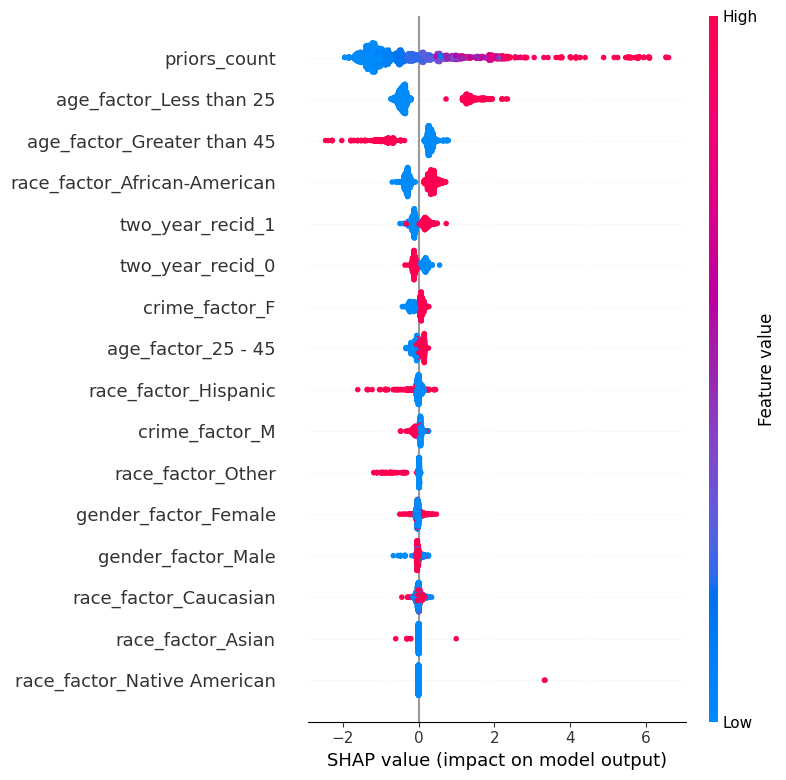

In [41]:
# SHAP summary plot

shap.summary_plot(shap_values, X_test_enc_dense, feature_names=feature_names)


SHAP waterfall: African-American_low


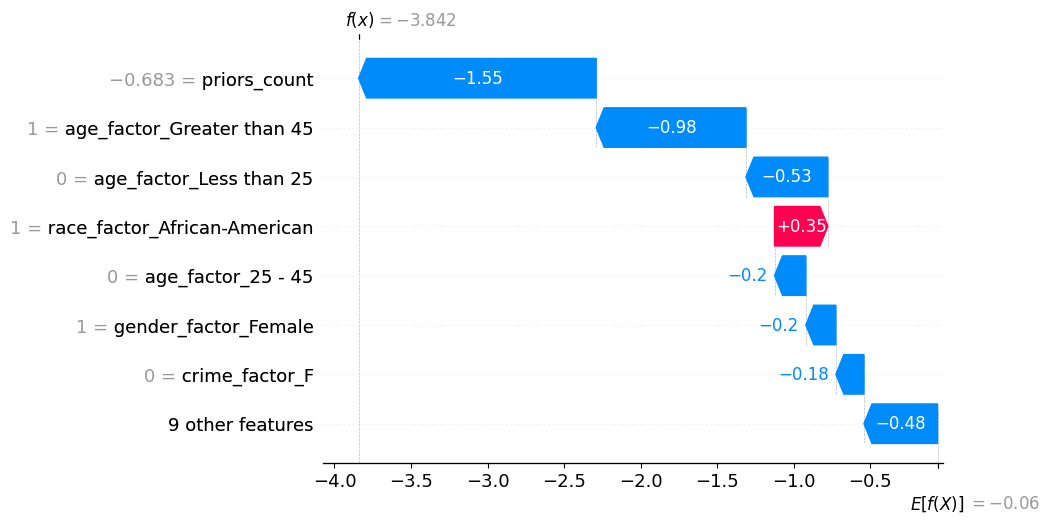


SHAP waterfall: African-American_high


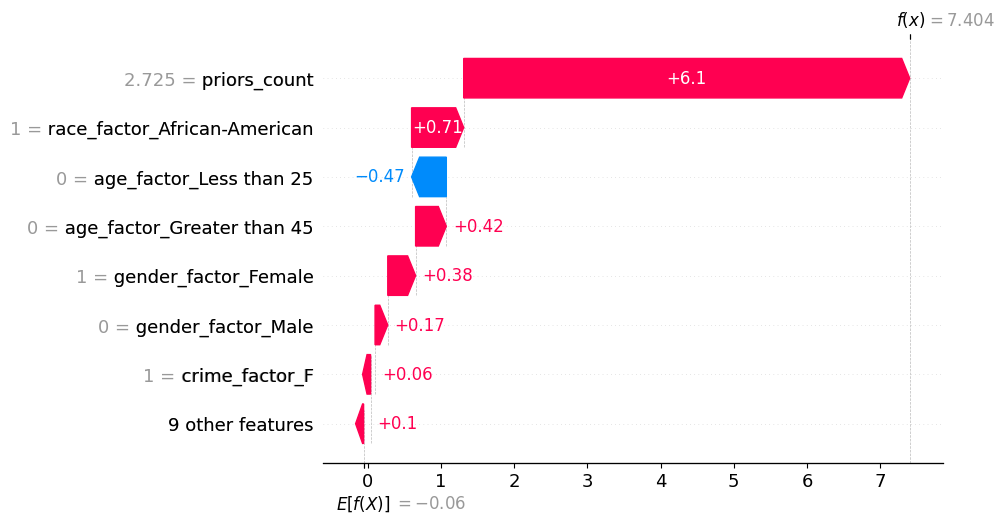


SHAP waterfall: Caucasian_low


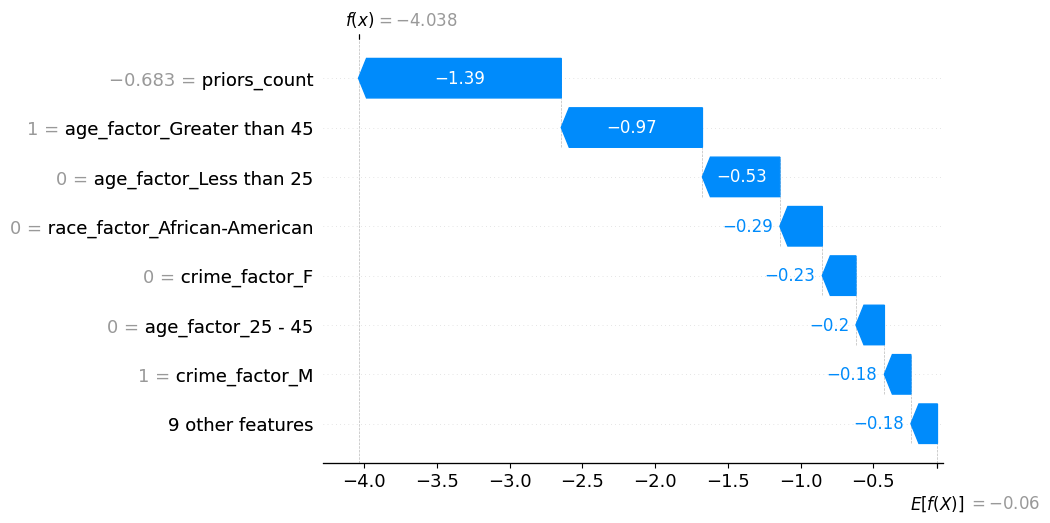


SHAP waterfall: Caucasian_high


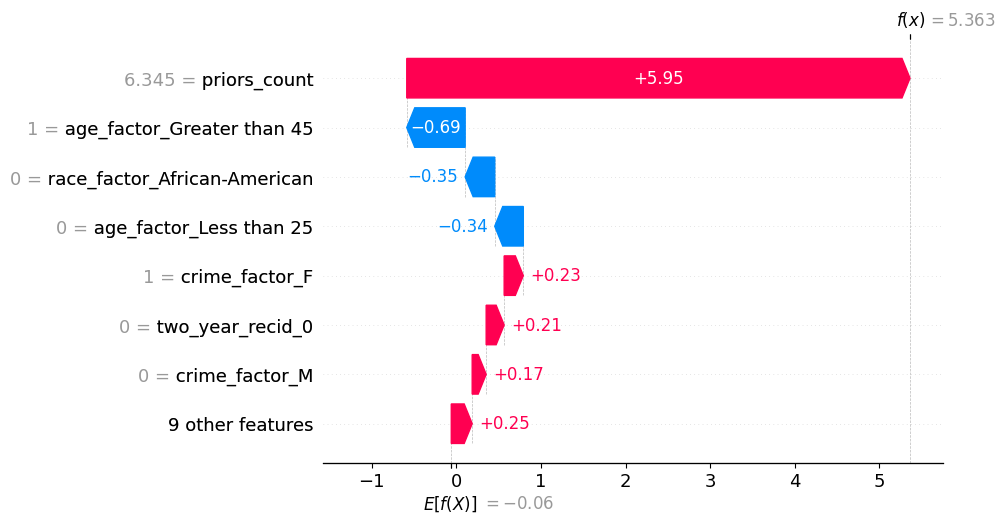

In [42]:
# SHAP explanations for individual predictions

for label, idx in selected_ids.items():
    loc = X_test.index.get_loc(idx)
    print(f"\nSHAP waterfall: {label}")
    shap.plots.waterfall(shap_values[loc], max_display=8)

In [43]:
# Compare top features from LIME and SHAP explanations

def top_shap_features(shap_values_obj, loc, feature_names, top_n=6):
    vals = shap_values_obj.values[loc]
    order = np.argsort(np.abs(vals))[::-1][:top_n]
    return [(feature_names[i], vals[i]) for i in order]

for label, idx in selected_ids.items():
    loc = X_test.index.get_loc(idx)
    print(f"\n--- Comparison for {label} ---")
    print("LIME top features:")
    for feat, weight in lime_results[label]:
        print(f"  {feat}: {weight:+.4f}")

    print("SHAP top features:")
    for feat, val in top_shap_features(shap_values, loc, feature_names):
        print(f"  {feat}: {val:+.4f}")


--- Comparison for African-American_low ---
LIME top features:
  age_factor_Less than 25 <= 0.00: -0.3460
  age_factor_Greater than 45 > 0.00: -0.2159
  0.00 < race_factor_African-American <= 1.00: +0.1136
  priors_count <= -0.68: -0.0625
  two_year_recid_1 <= 0.00: -0.0419
  0.00 < two_year_recid_0 <= 1.00: -0.0378
SHAP top features:
  priors_count: -1.5518
  age_factor_Greater than 45: -0.9785
  age_factor_Less than 25: -0.5349
  race_factor_African-American: +0.3482
  age_factor_25 - 45: -0.2044
  gender_factor_Female: -0.1962

--- Comparison for African-American_high ---
LIME top features:
  priors_count > 0.17: +0.3841
  age_factor_Less than 25 <= 0.00: -0.3429
  age_factor_Greater than 45 <= 0.00: +0.2240
  0.00 < race_factor_African-American <= 1.00: +0.1064
  race_factor_Hispanic <= 0.00: +0.0883
  two_year_recid_1 <= 0.00: -0.0457
SHAP top features:
  priors_count: +6.0959
  race_factor_African-American: +0.7120
  age_factor_Less than 25: -0.4746
  age_factor_Greater than 45:

Both LIME and SHAP agree that priors_count and age are the top drivers of predictions across all four defendants, giving confidence these are the model's most influential features.
Where they diverge is in the ranking of secondary features. LIME occasionally surfaces specific categorical values more prominently than SHAP does for the same individual. This is because LIME fits a local approximation using perturbed samples, making it less stable across runs, while SHAP distributes credit consistently across all feature coalitions.
For governance, this means LIME alone is not reliable enough to justify or challenge an individual decision. SHAP is more defensible in a formal audit due to its axiomatic properties, but neither method should be used in isolation, both are approximations of the true model internals.

In [44]:
# Import counterfactual explanation library

import dice_ml
from dice_ml import Dice

In [45]:
# Set up DiCE counterfactual explanation framework

dice_train_df = X_train.copy()
dice_train_df[target] = y_train.values

dice_data = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

In [46]:
# Create counterfactual explanations for selected cases

counterfactual_results = {}

for label, idx in selected_ids.items():
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=1,
        desired_class="opposite",
        features_to_vary=["priors_count", "crime_factor", "age_factor"],
        permitted_range={"priors_count": [0, int(df["priors_count"].max())]}
    )

    counterfactual_results[label] = cf
    print(f"\nDiCE counterfactual: {label}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.00it/s]


DiCE counterfactual: African-American_low
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,Female,Greater than 45,African-American,0,M,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,-,Less than 25,-,24,-,-,1


...

100%|██████████| 1/1 [00:00<00:00,  4.71it/s]


DiCE counterfactual: Caucasian_high
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,Male,Greater than 45,Caucasian,33,F,1,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_factor
0,-,-,-,15,-,-,0


In [47]:
# Verify counterfactuals did not change immutable features

immutable_features = ["race_factor", "gender_factor"]

for label, cf_obj in counterfactual_results.items():
    print(f"\nImmutable-feature check: {label}")
    try:
        cf_df = cf_obj.cf_examples_list[0].final_cfs_df
        original = X_test.loc[[selected_ids[label]]].reset_index(drop=True)

        for col in immutable_features:
            changed = not cf_df[col].eq(original.loc[0, col]).all()
            print(f"{col}: {'CHANGED' if changed else 'unchanged'}")
    except Exception as e:
        print("Could not parse counterfactual output cleanly:", e)


Immutable-feature check: African-American_low
race_factor: unchanged
gender_factor: unchanged

Immutable-feature check: African-American_high
race_factor: unchanged
gender_factor: unchanged

Immutable-feature check: Caucasian_low
race_factor: unchanged
gender_factor: unchanged

Immutable-feature check: Caucasian_high
race_factor: unchanged
gender_factor: unchanged


In [48]:
# Summary of selected individuals and model predictions

selected_summary = X_test.loc[list(selected_ids.values())].copy()
selected_summary["label"] = list(selected_ids.keys())
selected_summary["pred_prob"] = gbt_pipeline.predict_proba(X_test.loc[list(selected_ids.values())])[:, 1]
selected_summary["actual_score_factor"] = y_test.loc[list(selected_ids.values())].values

selected_summary

,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,label,pred_prob,actual_score_factor
4008,Female,Greater than 45,African-American,0,M,0,African-American_low,0.020935,0
5311,Female,25 - 45,African-American,16,F,0,African-American_high,0.999390,1
2517,Female,Greater than 45,Caucasian,0,M,0,Caucasian_low,0.017269,0
2441,Male,Greater than 45,Caucasian,33,F,1,Caucasian_high,0.995320,1


To: Court Auditor

Subject: Model Governance Review

Date: March 30, 2026

This memo summarizes findings of a COMPAS replacement risk model using logistic regression and gradient-boosted trees, along with explanation methods including SHAP, LIME, and counterfactual explanations. These methods were applied to 4 individuals, the highest and lowest-risk Black and White defendants in the dataset.

The explanation methods revealed that the model's predictions are primarily driven by prior criminal history, charge degree, and age category, with smaller contributions from demographic variables. Both SHAP and LIME indicated that individuals with a higher number of prior offenses and more serious charges were more likely to receive a high-risk prediction. In general, SHAP provided more stable global explanations across the dataset, while LIME provided more localized explanations for individual cases.

However, the explanation methods also have limitations. LIME explanations depend on local neighborhood sampling and can vary across runs, making them less stable for governance purposes. SHAP explanations are more consistent but can be computationally expensive as they require evaluating all possible feature coalitions. Counterfactual explanations were useful for showing what minimal changes would flip a prediction, but some counterfactuals may suggest changes that are unrealistic or involve immutable characteristics such as race or gender. These should not be interpreted as actionable recommendations.

The fairness analysis showed differences in error rates across racial groups, particularly in false positive and false negative rates. This indicates that model performance is not uniform across groups and should be monitored carefully. Explanation methods help understand model behavior but do not guarantee fairness or absence of bias.

I recommend ongoing monitoring of model performance by demographic group, periodic auditing of explanation outputs, and documentation of feature importance and counterfactual behavior. Immutable features such as race and gender should not be used in counterfactual recourse recommendations. Governance procedures should include regular fairness audits, model documentation, and human review for high-risk decisions to ensure the model is used responsibly and transparently.

In [49]:
!pip install solas-ai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.6 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=adbd5eade43f70a99562d7dc064efbe452bbc5c99a358ecc49887904db1c0ea1
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import solas_disparity as sd
import warnings
from statsmodels.stats.proportion import proportions_ztest

warnings.filterwarnings("ignore")

In [51]:
def prep_solas(df, group_col):
    """Return a one-hot encoded copy with the original numeric columns kept."""
    numeric_cols = [c for c in df.columns if c not in [group_col]]
    dummies = pd.get_dummies(df[[group_col]], columns=[group_col])
    return pd.concat([df[numeric_cols], dummies], axis=1)

In [52]:
df_race = prep_solas(df, "race")

race_groups = ["race_African-American", "race_Hispanic",
               "race_Asian", "race_Native American", "race_Other"]
race_refs   = ["race_Caucasian"] * len(race_groups)
race_cats   = ["race"]           * len(race_groups)

# AIR by race
air_race = sd.adverse_impact_ratio(
    group_data               = df_race,
    protected_groups         = race_groups,
    reference_groups         = race_refs,
    group_categories         = race_cats,
    outcome                  = df_race["score_factor"],
    air_threshold            = 0.80,
    percent_difference_threshold = 0.05,
)

print("AIR by Race  (solas-ai):")

print(air_race.summary_table[
    ["Reference Group", "Percent Favorable", "AIR",
     "P-Values", "Practically Significant"]
].to_string())

# ME by race
print("\n── Marginal Effect (ME) by Race ──")
ref_rate_race = df["score_factor"][df["race"] == "Caucasian"].mean()
me_race = (
    df.groupby("race")["score_factor"]
    .mean()
    .rename("Selection Rate")
    .reset_index()
)
me_race["ME"] = (me_race["Selection Rate"] - ref_rate_race).round(4)
print(me_race.sort_values("ME", ascending=False).to_string(index=False))

# SMD by race
smd_race = sd.standardized_mean_difference(
    group_data       = df_race,
    protected_groups = race_groups,
    reference_groups = race_refs,
    group_categories = race_cats,
    outcome          = df_race["decile_score"],
    smd_threshold    = 0.20,
)
print("\n── SMD by Race ──")
print(smd_race.summary_table[
    ["Reference Group", "Average Outcome", "Difference in Average Outcome",
     "SMD", "P-Values", "Practically Significant"]
].to_string())

# AIR, ME, SMD  for  SEX

df_sex = prep_solas(df, "sex")

sex_groups = ["sex_Female"]
sex_refs   = ["sex_Male"]
sex_cats   = ["sex"]

# AIR by sex
air_sex = sd.adverse_impact_ratio(
    group_data               = df_sex,
    protected_groups         = sex_groups,
    reference_groups         = sex_refs,
    group_categories         = sex_cats,
    outcome                  = df_sex["score_factor"],
    air_threshold            = 0.80,
    percent_difference_threshold = 0.05,
)

print("AIR by Sex  (solas-ai):")

print(air_sex.summary_table[
    ["Reference Group", "Percent Favorable", "AIR",
     "P-Values", "Practically Significant"]
].to_string())

# ME by sex
print("\n── Marginal Effect (ME) by Sex ──")
ref_rate_sex = df["score_factor"][df["sex"] == "Male"].mean()
me_sex = (
    df.groupby("sex")["score_factor"]
    .mean()
    .rename("Selection Rate")
    .reset_index()
)
me_sex["ME"] = (me_sex["Selection Rate"] - ref_rate_sex).round(4)
print(me_sex.to_string(index=False))

# SMD by sex
smd_sex = sd.standardized_mean_difference(
    group_data       = df_sex,
    protected_groups = sex_groups,
    reference_groups = sex_refs,
    group_categories = sex_cats,
    outcome          = df_sex["decile_score"],
    smd_threshold    = 0.20,
)
print("\n── SMD by Sex ──")
print(smd_sex.summary_table[
    ["Reference Group", "Average Outcome", "Difference in Average Outcome",
     "SMD", "P-Values", "Practically Significant"]
].to_string())


print("Confirming solas-ai matches manual calculation:")


manual_sr_race  = df.groupby("race")["score_factor"].mean()
manual_air_race = (manual_sr_race / manual_sr_race["Caucasian"]).rename("Manual AIR")

solas_tbl_race = air_race.summary_table["AIR"].rename("Solas AIR")
solas_tbl_race.index = solas_tbl_race.index.str.replace("race_", "")

compare_race = pd.concat([manual_air_race, solas_tbl_race], axis=1).dropna()
compare_race["Match?"] = pd.Series(
    np.isclose(compare_race["Manual AIR"], compare_race["Solas AIR"], atol=1e-4),
    index=compare_race.index
).map({True: "✓ identical", False: "✗ differs"})
print("\n  Race AIR comparison:")
print(compare_race.to_string())

manual_sr_sex  = df.groupby("sex")["score_factor"].mean()
manual_air_sex = manual_sr_sex["Female"] / manual_sr_sex["Male"]
solas_air_sex  = air_sex.summary_table.loc["sex_Female", "AIR"]
match_sex = "✓ identical" if np.isclose(manual_air_sex, solas_air_sex, atol=1e-4) else "✗ differs"
print(f"\n  Sex AIR — Manual: {manual_air_sex:.6f}  |  "
      f"Solas: {solas_air_sex:.6f}  |  {match_sex}")


AIR by Race  (solas-ai):
                      Reference Group  Percent Favorable       AIR      P-Values Practically Significant
Group                                                                                                   
race_African-American  race_Caucasian           0.576063  1.740604  5.425755e-68                      No
race_Hispanic          race_Caucasian           0.277014  0.837011  2.218706e-02                      No
race_Asian             race_Caucasian           0.225806  0.682286  2.521538e-01                      No
race_Native American   race_Caucasian           0.727273  2.197492  8.612986e-03                      No
race_Other             race_Caucasian           0.204082  0.616643  1.635837e-06                     Yes
race_Caucasian                                  0.330956       NaN           NaN                        

── Marginal Effect (ME) by Race ──
            race  Selection Rate      ME
 Native American        0.727273  0.3963
African-American 

In [53]:
df["subgroup"] = df["race"].astype(str) + " / " + df["sex"].astype(str)
valid_sg = df["subgroup"].value_counts()
valid_sg = valid_sg[valid_sg >= 30].index
df_sub   = df[df["subgroup"].isin(valid_sg)].copy()

sub_rates = (
    df_sub.groupby("subgroup")["score_factor"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Selection Rate", "count": "n"})
    .reset_index()
)
ref_rate_inter = sub_rates.loc[
    sub_rates["subgroup"] == "Caucasian / Male", "Selection Rate"
].values[0]

sub_rates["AIR"]  = sub_rates["Selection Rate"] / ref_rate_inter
sub_rates["flag"] = sub_rates["AIR"].apply(
    lambda x: "*** BELOW 0.80" if x < 0.80 else ""
)
worst = sub_rates.loc[sub_rates["AIR"].idxmin()]


print("Intersectional AIR  (Race × Sex):")

print(sub_rates.sort_values("AIR").to_string(index=False))
print(f"\n▶ Worst group : {worst['subgroup']}")
print(f"  AIR = {worst['AIR']:.3f}  (n = {int(worst['n'])})")
print(
    f"\n  Interpretation:\n"
    f"  '{worst['subgroup']}' defendants are assigned a high-risk score at only\n"
    f"  {worst['AIR']*100:.1f}% of the rate of Caucasian / Male defendants (the reference\n"
    f"  group). An AIR this far below the 4/5ths rule threshold of 0.80 signals\n"
    f"  strong evidence of disparate impact at the intersectional level. This\n"
    f"  group's low base selection rate is driven by the 'Other' race category\n"
    f"  having an overall low predicted-risk rate; the combined female + 'Other'\n"
    f"  effect amplifies this disparity. The small sample (n={int(worst['n'])}) means\n"
    f"  the estimate is statistically uncertain and should be interpreted cautiously."
)

Intersectional AIR  (Race × Sex):
                 subgroup  Selection Rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

▶ Worst group : Hispanic / Female
  AIR = 0.270  (n = 82)

  Interpretation:
  'Hispanic / Female' defendants are assigned a high-risk score at only
  27.0% of the rate of Caucasian / Male defendants (the reference
  group). An AIR this far below the 4/5ths rule threshold of 0.80 signals
  strong evidence of disparate impact

In [54]:

print("FPR & FNR Disparities by Race + Z-tests:")


def compute_error_rates(df):
    rows = []
    for grp, g in df.groupby("race"):
        tp = int(((g["pred_class"] == 1) & (g["two_year_recid"] == 1)).sum())
        tn = int(((g["pred_class"] == 0) & (g["two_year_recid"] == 0)).sum())
        fp = int(((g["pred_class"] == 1) & (g["two_year_recid"] == 0)).sum())
        fn = int(((g["pred_class"] == 0) & (g["two_year_recid"] == 1)).sum())
        rows.append({
            "race": grp, "n": len(g),
            "FP": fp, "TN": tn, "FN": fn, "TP": tp,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        })
    return pd.DataFrame(rows)

er = compute_error_rates(df)
print(er[["race", "n", "FPR", "FNR"]].sort_values("FPR", ascending=False).to_string(index=False))

# Two-proportion z-tests
aa  = er[er["race"] == "African-American"].iloc[0]
cau = er[er["race"] == "Caucasian"].iloc[0]

fpr_z, fpr_p = proportions_ztest(
    count=[aa["FP"],  cau["FP"]],
    nobs =[aa["FP"] + aa["TN"],  cau["FP"] + cau["TN"]],
    alternative="two-sided"
)
fnr_z, fnr_p = proportions_ztest(
    count=[aa["FN"],  cau["FN"]],
    nobs =[aa["FN"] + aa["TP"],  cau["FN"] + cau["TP"]],
    alternative="two-sided"
)

print(f"\n── Two-Proportion Z-Tests (African-American vs. Caucasian) ──")
print(f"FPR: AA={aa['FPR']:.3f}  Cau={cau['FPR']:.3f}  "
      f"z={fpr_z:+.3f}  p={fpr_p:.2e}  "
      f"{'*** significant' if fpr_p < 0.05 else 'not significant'}")
print(f"FNR: AA={aa['FNR']:.3f}  Cau={cau['FNR']:.3f}  "
      f"z={fnr_z:+.3f}  p={fnr_p:.2e}  "
      f"{'*** significant' if fnr_p < 0.05 else 'not significant'}")
print(f"\nAfrican-American FPR is {aa['FPR']/cau['FPR']:.1f}x the Caucasian FPR.")
print(f"Caucasian FNR is {cau['FNR']/aa['FNR']:.1f}x the African-American FNR.")


FPR & FNR Disparities by Race + Z-tests:
            race    n      FPR      FNR
 Native American   11 0.666667 0.000000
African-American 3175 0.366579 0.173390
       Caucasian 2103 0.103825 0.536496
        Hispanic  509 0.043750 0.571429
           Asian   31 0.043478 0.750000
           Other  343 0.013699 0.822581

── Two-Proportion Z-Tests (African-American vs. Caucasian) ──
FPR: AA=0.367  Cau=0.104  z=+16.068  p=4.31e-58  *** significant
FNR: AA=0.173  Cau=0.536  z=-18.697  p=5.27e-78  *** significant

African-American FPR is 3.5x the Caucasian FPR.
Caucasian FNR is 3.1x the African-American FNR.


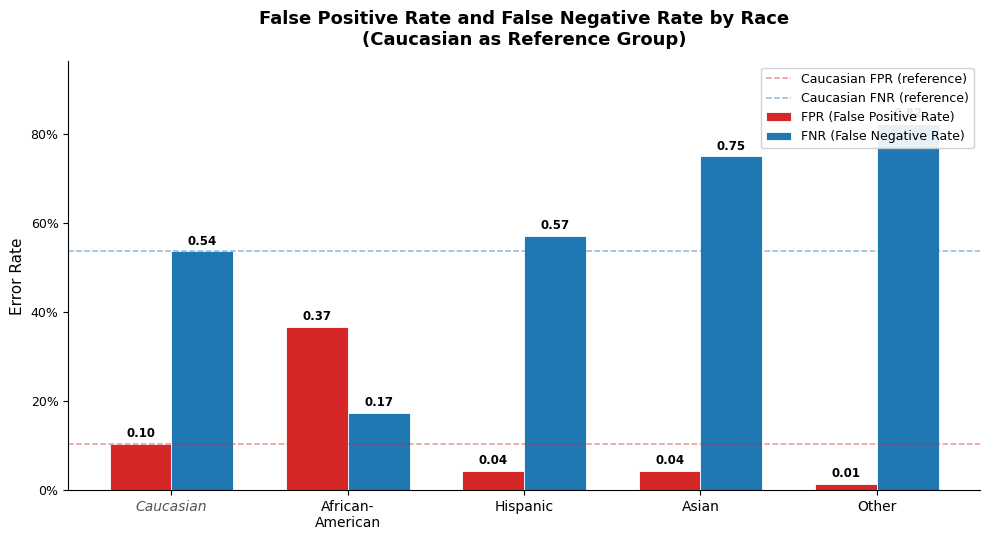

Figure saved → FPR_FNR_by_race.png


In [55]:
# Keep only groups with n >= 30
plot_df = er[er["n"] >= 30].copy()

# Caucasian (reference), then remaining sorted by FPR descending
non_cau = plot_df[plot_df["race"] != "Caucasian"].sort_values("FPR", ascending=False)
plot_df = pd.concat(
    [plot_df[plot_df["race"] == "Caucasian"], non_cau]
).reset_index(drop=True)

labels = [r.replace("-", "-\n") for r in plot_df["race"]]
x      = np.arange(len(plot_df))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))

bar1 = ax.bar(x - width/2, plot_df["FPR"], width,
              label="FPR (False Positive Rate)",
              color="#d62728", edgecolor="white", linewidth=0.6)
bar2 = ax.bar(x + width/2, plot_df["FNR"], width,
              label="FNR (False Negative Rate)",
              color="#1f77b4", edgecolor="white", linewidth=0.6)


ref_fpr = plot_df.loc[plot_df["race"] == "Caucasian", "FPR"].values[0]
ref_fnr = plot_df.loc[plot_df["race"] == "Caucasian", "FNR"].values[0]
ax.axhline(ref_fpr, color="#d62728", linestyle="--", linewidth=1.1,
           alpha=0.5, label="Caucasian FPR (reference)")
ax.axhline(ref_fnr, color="#1f77b4", linestyle="--", linewidth=1.1,
           alpha=0.5, label="Caucasian FNR (reference)")

# Value labels on each bar
for bar in [bar1, bar2]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, h + 0.008,
                f"{h:.2f}", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Error Rate", fontsize=11)
ax.set_ylim(0, max(plot_df["FNR"].max(), plot_df["FPR"].max()) + 0.14)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title(
    "False Positive Rate and False Negative Rate by Race\n"
    "(Caucasian as Reference Group)",
    fontsize=13, fontweight="bold", pad=12
)
ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)
ax.get_xticklabels()[0].set_fontstyle("italic")
ax.get_xticklabels()[0].set_color("#555555")

plt.tight_layout()
plt.savefig("FPR_FNR_by_race.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved → FPR_FNR_by_race.png")

To: Regulatory Compliance Officer

Subject: Disparate Impact Audit

Date: April 6, 2026

Overview

This memo summarises a disparate impact audit of a recidivism risk classification system using the cleaned COMPAS two-year recidivism dataset. Fairness metrics computed included Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardised Mean Difference (SMD). Error-rate disparities were evaluated using False Positive Rate (FPR) and False Negative Rate (FNR), with statistical significance assessed using two-proportion z-tests. Intersectional subgroup analysis (race × sex) was also conducted.

Key Findings

African-American defendants were assigned high-risk predictions at approximately 2.48 times the rate of Caucasian defendants (AIR = 2.48, ME = +0.36, p < 0.0001). The Standardised Mean Difference on decile score was 0.61, indicating a large difference in score distributions. Hispanic, Asian, and Other defendants showed AIR values below 0.80 relative to Caucasian defendants, indicating under-selection relative to the reference group.

Female defendants had an AIR of approximately 0.93 relative to male defendants, which is above the four-fifths rule threshold. Differences by sex were small and not statistically significant.

African-American defendants experienced a False Positive Rate of 0.367 compared to 0.104 for Caucasian defendants, representing a statistically significant disparity. Conversely, Caucasian defendants had a higher False Negative Rate, indicating differing error distributions across groups.

The worst intersectional subgroup was “Other / Female,” although the small sample size limits the reliability of this estimate.

Limitations

The outcome variable measures re-arrest rather than actual re-offending and may reflect policing practices. Small subgroup sizes reduce statistical stability, and results are specific to Broward County and may not generalise to other jurisdictions.

Recommendation

The observed disparity in false positive rates represents a material fairness concern. Deployment should include ongoing monitoring, periodic bias audits, and evaluation of alternative modeling approaches before operational use.